# Validación de Modelo Computacional: Simulación vs Sensores

## 1. Objetivo

Este notebook evalúa la velocidad y dirección del viento simuladas computacionalmente, esto mediante su comparación con observaciones horarias de la red de monitoreo RAMM.

El análisis se enfoca en los siguientes puntos:

- construir un dataset consistente para la validación a nivel de estación
- alinear observaciones y simulaciones para estación y timestamp
- cuantificar el error en velocidad del viento y su concordancia temporal
- evaluar la dirección del viento mediante estadística circular debido a su naturaleza
- identificar diferencias en el desempeño entre estaciones
- analizar la sensibilidad del error bajo condiciones especificas de vientos débiles

## 2. Datos

Dos fuentes de datos fueron utilizadas para este análisis.

- Observaciones en superficie: mediciones horarias de velocidad y dirección del viento provenientes de sensores en estaciones meteorológicas (red RAMM).
- Datos simulados: resultados obtenidos mediante simulaciones realizadas en un modelo atmosférico, con dichos datos previamente asociados espacialmente con las ubicaciones correspondientes de las estaciones físicas RAMM.

Los datos fueron generados mediante el modelo Weather Research and Forecasting (WRF). Para mantener claridad en el flujo de validación, se utilizan los nombres `wind_sim` y `dir_sim` para las variables simuladas (velocidad y dirección del viento) y `wind_obs` y `dir_obs` para las variables observadas por la red RAMM.

In [1]:
from pathlib import Path
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde


# paths
DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 3. Preparación de los Datos

Antes de realizar la validación, ambos datasets se estandarizan a una estructura común:

- convertir los timestamps al formato datetime
- estandarizar los identificadores de estación
- conservar únicamente las variables de velocidad y dirección del viento
- expresar la velocidad del viento en metros por segundo (m/s) para ambos conjuntos
- eliminar registros inválidos o faltantes

La simulación comprende el periodo desde el 1 de marzo de 2024 a las 00:00 hasta el 31 de mayo de 2024 a las 23:00, con una resolución temporal horaria.

Los timestamps de la simulación ya se encuentran almacenados en la referencia temporal utilizada para la comparación, por lo que no se aplica ningún ajuste horario adicional.

Por defecto, los resultados arrojados por la simulación para la velocidad del viento son expresados en m/s, mismas unidades utilizadas por las observaciones de la red RAMM, con excepción de la estación R17, cuyos valores son convertidos de km/h a m/s.

In [2]:
# Carga y estandarización de los datos de la red RAMM

observation_frames = []

observation_files = sorted(DATA_DIR.glob("ramm*.csv"))

if not observation_files:
    raise FileNotFoundError("No RAMM observation files were found in ../data/")


for file_path in observation_files:

    base_name = file_path.stem.lower()

    # Estandarizar variables
    if base_name == "rammcu2":
        station = "RCU"
    else:
        station = "R" + base_name.replace("ramm", "")

    # Some source files contain duplicated quotation marks.
    with open(file_path, "r", encoding="utf-8") as file:
        clean_text = "\n".join(
            line.strip().strip('"').replace('""', '')
            for line in file
        )

    station_df = pd.read_csv(
        io.StringIO(clean_text),
        sep=",",
        index_col=False
    )

    required_columns = {"date", "ws", "wd"}

    if not required_columns.issubset(station_df.columns):
        missing = required_columns - set(station_df.columns)

        raise ValueError(
            f"{file_path.name} is missing required columns: {missing}"
    )


    station_df = station_df.rename(
        columns={
            "date": "timestamp",
            "ws": "wind_obs",
            "wd": "dir_obs"
        }
    )

    station_df["timestamp"] = pd.to_datetime(
        station_df["timestamp"],
        format="mixed",
        errors="coerce"
    )

    # R17 está en km/h -> convertir a m/s
    if station == "R17":
        station_df["wind_obs"] = station_df["wind_obs"] / 3.6

    station_df["station"] = station

    station_df = station_df[
        ["station", "timestamp", "wind_obs", "dir_obs"]
    ]

    observation_frames.append(station_df)


observations_df = pd.concat(
    observation_frames,
    ignore_index=True
)

observations_df = (
    observations_df
    .dropna(subset=["station", "timestamp", "wind_obs", "dir_obs"])
    .sort_values(["station", "timestamp"])
    .reset_index(drop=True)
)

observations_df.head()

,station,timestamp,wind_obs,dir_obs
0,R00,2024-03-01 00:00:00,12.1,165.0
1,R00,2024-03-01 01:00:00,11.6,158.7
2,R00,2024-03-01 02:00:00,8.6,160.8
3,R00,2024-03-01 03:00:00,6.0,115.6
4,R00,2024-03-01 04:00:00,7.4,60.1


In [3]:
# Carga y estandarización de los datos de la simulación

simulation_raw = pd.read_csv(
    DATA_DIR / "viento_red_ramm_2024.csv"
)

simulation_df["timestamp"] = pd.to_datetime(
    simulation_df["timestamp"],
    format="mixed",
    errors="coerce"
)

simulation_df = simulation_df[
    ["station", "timestamp", "wind_sim", "dir_sim"]
]

simulation_df = (
    simulation_df
    .dropna(subset=["station", "timestamp", "wind_sim", "dir_sim"])
    .sort_values(["station", "timestamp"])
    .reset_index(drop=True)
)

simulation_df.head()

,station,timestamp,wind_sim,dir_sim
0,R00,2024-03-01 00:00:00,5.033333,184.24
1,R00,2024-03-01 01:00:00,2.769444,181.05
2,R00,2024-03-01 02:00:00,2.350000,180.74
3,R00,2024-03-01 03:00:00,2.425000,162.20
4,R00,2024-03-01 04:00:00,3.516667,102.93


### Calidad de Datos

Antes de combinar ambos conjuntos, se verifica que no existan combinaciones duplicadas de `station` y `timestamp`.

In [4]:
# Calidad de datos y duplicados
obs_duplicates = observations_df.duplicated(
    subset=["station", "timestamp"]
).sum()

sim_duplicates = simulation_df.duplicated(
    subset=["station", "timestamp"]
).sum()

print(f"Observation duplicate station-hours: {obs_duplicates}")
print(f"Simulation duplicate station-hours:  {sim_duplicates}")

print()
print(f"Observation stations: {observations_df['station'].nunique()}")
print(f"Simulation stations:  {simulation_df['station'].nunique()}")

Observation duplicate station-hours: 0
Simulation duplicate station-hours:  0

Observation stations: 19
Simulation stations:  19


In [5]:
if obs_duplicates > 0 or sim_duplicates > 0:
    raise ValueError(
        "Duplicate station-timestamp combinations detected. "
        "Resolve duplicates before validation."
    )

## 4. Alineación Temporal

Las observaciones y simulaciones se emparejan utilizando dos variables:

- `station`
- `timestamp`

Para ello se utiliza un inner join, por lo que únicamente se conservan las horas para las cuales existe información disponible tanto en las observaciones como en la simulación.

La simulación cubre de manera continua el periodo comprendido entre el 1 de marzo de 2024 a las 00:00 y el 31 de mayo de 2024 a las 23:00. Debido a que el modelo genera resultados a intervalos horarios regulares, se espera que el dataset simulado presente una cobertura temporal más completa que las observaciones de la red de monitoreo, las cuales pueden contener horas faltantes debido a factores propios de los sensores.

Por esta razón, las estadísticas de cobertura (`coverage_df`) describen la disponibilidad de datos para validación y no deben interpretarse como métricas de desempeño del modelo.

Únicamente las combinaciones estación-hora disponibles en ambos datasets se conservan en `validation_df`, que constituye el dataset utilizado en el resto del notebook.

In [6]:
# Alineación temporal

validation_df = pd.merge(
    observations_df,
    simulation_df,
    on=["station", "timestamp"],
    how="inner",
    validate="one_to_one"
)

validation_df = (
    validation_df
    .dropna()
    .sort_values(["station", "timestamp"])
    .reset_index(drop=True)
)


# Temporal coverage esperada

simulation_start = pd.Timestamp("2024-03-01 00:00")
simulation_end = pd.Timestamp("2024-05-31 23:00")

expected_hours_per_station = len(
    pd.date_range(
        simulation_start,
        simulation_end,
        freq="h"
    )
)

stations_evaluated = validation_df["station"].nunique()

expected_station_hours = (
    expected_hours_per_station * stations_evaluated
)


# Conteo de registros

n_obs = len(observations_df)
n_sim = len(simulation_df)
n_matched = len(validation_df)


obs_coverage = 100 * n_matched / n_obs
sim_coverage = 100 * n_matched / n_sim

validation_coverage = (
    100 * n_matched / expected_station_hours
)


alignment_summary = pd.DataFrame({
    "Metric": [
        "Inicio de la simulación",
        "Fin de la simulación",
        "Horas esperadas por estación",
        "Estaciones evaluadas",
        "Horas totales esperadas",
        "Observaciones disponibles",
        "Datos simulados disponibles",
        "Registros estación-hora emparejados",
        "Observaciones con simulación disponible (%)",
        "Simulaciones con observación disponible (%)",
        "Cobertura total de validación (%)"
    ],
    "Value": [
        simulation_start,
        simulation_end,
        expected_hours_per_station,
        stations_evaluated,
        expected_station_hours,
        n_obs,
        n_sim,
        n_matched,
        round(obs_coverage, 1),
        round(sim_coverage, 1),
        round(validation_coverage, 1)
    ]
})

alignment_summary

,Metric,Value
0,Inicio de la simulación,2024-03-01 00:00:00
1,Fin de la simulación,2024-05-31 23:00:00
2,Horas esperadas por estación,2208
3,Estaciones evaluadas,19
4,Horas totales esperadas,41952
5,Observaciones disponibles,40083
6,Datos simulados disponibles,41952
7,Registros estación-hora emparejados,40083
8,Observaciones con simulación disponible (%),100.0
9,Simulaciones con observación disponible (%),95.5


In [7]:
obs_counts = (
    observations_df
    .groupby("station")
    .size()
    .rename("obs_hours")
)

sim_counts = (
    simulation_df
    .groupby("station")
    .size()
    .rename("sim_hours")
)

matched_counts = (
    validation_df
    .groupby("station")
    .size()
    .rename("matched_hours")
)


coverage_df = pd.concat(
    [
        obs_counts,
        sim_counts,
        matched_counts
    ],
    axis=1
).fillna(0)

coverage_df["expected_hours"] = expected_hours_per_station

coverage_df["obs_coverage_pct"] = (
    100
    * coverage_df["obs_hours"]
    / expected_hours_per_station
)

coverage_df["sim_coverage_pct"] = (
    100
    * coverage_df["sim_hours"]
    / expected_hours_per_station
)

coverage_df["validation_coverage_pct"] = (
    100
    * coverage_df["matched_hours"]
    / expected_hours_per_station
)

coverage_df = (
    coverage_df
    .reset_index()
    .round(2)
    .sort_values(
        "validation_coverage_pct",
        ascending=False
    )
)

coverage_df

,station,obs_hours,sim_hours,matched_hours,expected_hours,obs_coverage_pct,sim_coverage_pct,validation_coverage_pct
0,R00,2208,2208,2208,2208,100.00,100.0,100.00
1,R01,2207,2208,2207,2208,99.95,100.0,99.95
16,R23,2207,2208,2207,2208,99.95,100.0,99.95
15,R22,2207,2208,2207,2208,99.95,100.0,99.95
14,R20,2207,2208,2207,2208,99.95,100.0,99.95
13,R17,2207,2208,2207,2208,99.95,100.0,99.95
12,R16,2207,2208,2207,2208,99.95,100.0,99.95
11,R15,2207,2208,2207,2208,99.95,100.0,99.95
9,R12,2207,2208,2207,2208,99.95,100.0,99.95
8,R10,2207,2208,2207,2208,99.95,100.0,99.95


### Resumen de Disponibilidad de los Datos

La simulación proporciona cobertura horaria completa para las 19 estaciones evaluadas, correspondiente a 2,208 horas por estación y 41,952 combinaciones estación-hora esperadas para toda la red.

En total, 40,083 combinaciones estación-hora estuvieron disponibles simultáneamente en ambos datasets, lo que representa una cobertura global de validación de aproximadamente 95.5%.

La estación R00 presenta cobertura observacional completa, mientras que la mayoría de las estaciones restantes sólo carecen de una observación horaria. Las mayores pérdidas de información se concentran en las estaciones R13, R05 y R24.

In [8]:
validation_df.head()

,station,timestamp,wind_obs,dir_obs,wind_sim,dir_sim
0,R00,2024-03-01 00:00:00,12.1,165.0,5.033333,184.24
1,R00,2024-03-01 01:00:00,11.6,158.7,2.769444,181.05
2,R00,2024-03-01 02:00:00,8.6,160.8,2.350000,180.74
3,R00,2024-03-01 03:00:00,6.0,115.6,2.425000,162.20
4,R00,2024-03-01 04:00:00,7.4,60.1,3.516667,102.93


## 5. Metodología de Validación

### Velocidad del Viento

El desempeño de la velocidad del viento se evalúa mediante las siguientes métricas:

- **Bias** — Error medio con signo entre los valores simulados y observados.
- **MAE** — Error absoluto medio.
- **RMSE** — Raíz del error cuadrático medio, el cual da un mayor peso a desviaciones grandes.
- **Pearson correlation ($r$)** — Mide la relación lineal entre la variabilidad temporal observada y simulada.

Un bias positivo indica que la simulación tiende a sobreestimar la velocidad del viento, mientras que un bias negativo indica una tendencia a subestimarla.

### Dirección del Viento

La dirección del viento es una variable periodica, por lo que una resta convencional entre direcciones puede producir errores artificialmente grandes.

La forma correcta de tratar errores para dicha variable consiste en la diferencia angular:

$$
e_\theta =
((\theta_{sim}-\theta_{obs}+180)\bmod 360)-180
$$

A partir de este error angular se calculan el Bias, MAE y RMSE direccionales.

In [9]:
def wind_speed_metrics(group):
    """Calculate wind-speed validation metrics for one station."""

    obs = group["wind_obs"]
    sim = group["wind_sim"]

    error = sim - obs

    if len(group) >= 2 and obs.nunique() > 1 and sim.nunique() > 1:
        pearson_r = stats.pearsonr(obs, sim).statistic
    else:
        pearson_r = np.nan

    return pd.Series({
        "N": len(group),
        "Bias (m/s)": error.mean(),
        "MAE (m/s)": error.abs().mean(),
        "RMSE (m/s)": np.sqrt(np.mean(error**2)),
        "Pearson r": pearson_r
    })


def angular_error(obs, sim):
    """Return shortest signed angular difference in degrees."""
    return ((sim - obs + 180) % 360) - 180


def wind_direction_metrics(group):
    """Calculate circular wind-direction validation metrics."""

    error = angular_error(
        group["dir_obs"],
        group["dir_sim"]
    )

    return pd.Series({
        "N": len(group),
        "Angular Bias (°)": error.mean(),
        "Angular MAE (°)": error.abs().mean(),
        "Angular RMSE (°)": np.sqrt(np.mean(error**2))
    })

## 6. Resultados por Estación

El desempeño se evaluó individualmente para cada estación con el objetivo de identificar si los errores presentan un comportamiento uniforme o si existen diferencias importantes dentro de la red de monitoreo.

In [10]:
speed_metrics = (
    validation_df
    .groupby("station")
    .apply(
        wind_speed_metrics,
        include_groups=False
    )
    .round(3)
)

direction_metrics = (
    validation_df
    .groupby("station")
    .apply(
        wind_direction_metrics,
        include_groups=False
    )
    .round(3)
)

In [11]:
speed_metrics

,N,Bias (m/s),MAE (m/s),RMSE (m/s),Pearson r
station,,,,,
R00,2208.0,-1.307,2.858,3.575,-0.006
R01,2207.0,1.344,2.876,3.578,-0.142
R03,2207.0,-0.963,2.483,3.050,-0.067
R05,1682.0,2.489,3.182,3.815,0.144
R06,2207.0,-1.700,3.356,4.240,-0.008
R07,2207.0,0.844,2.126,2.515,-0.148
R08,2207.0,0.664,2.188,2.581,-0.131
R09,2207.0,-1.915,3.367,4.314,0.143
R10,2207.0,1.830,2.548,3.158,-0.169


In [12]:
direction_metrics

,N,Angular Bias (°),Angular MAE (°),Angular RMSE (°)
station,,,,
R00,2208.0,24.521,72.492,86.585
R01,2207.0,-36.351,101.959,117.145
R03,2207.0,28.056,90.466,103.945
R05,1682.0,-23.748,108.701,124.196
R06,2207.0,22.179,79.626,95.829
R07,2207.0,14.988,76.822,91.643
R08,2207.0,5.543,75.756,91.717
R09,2207.0,-12.983,85.426,101.455
R10,2207.0,5.562,76.319,91.399


### Interpretación

Los errores de velocidad del viento muestran una variabilidad considerable entre las estaciones de monitoreo. Algunas estaciones presentan valores relativamente bajos de MAE y RMSE, mientras que otras muestran desviaciones notablemente mayores.
Por otro lado, las correlaciones de Pearson son débiles entre las estaciones evaluadas, lo que indica que una similitud razonable en la magnitud de la velocidad del viento no indica que el modelo capte adecuadamente su variabilidad horaria.

Bias, MAE, RMSE y Pearson $r$ se interpretan de manera conjunta, ya que cada métrica representa un aspecto diferente del desempeño de la simulación.

## 7. Gráficas

Las siguientes visualizaciones representan:

1. La relación global entre velocidad observada y simulada
2. Las diferencias del error entre estaciones
3. El comportamiento temporal en estaciones representativas,
4. y la distribución del error en dirección del viento.

### 7.1 Velocidad del Viento Observada vs Simulada

La relación global entre la velocidad del viento observada y simulada se analiza mediante un scatter plot acompañado de una línea de referencia 1:1. Las líneas de densidad permiten identificar las regiones con mayor concentración de observaciones emparejadas, pudiendo identificar regiones de mayor densidad de puntos a menores velocidades observadas; por otro lado, las métricas mostradas en la figura proporcionan información complementaria sobre la magnitud del error y el número de registros.

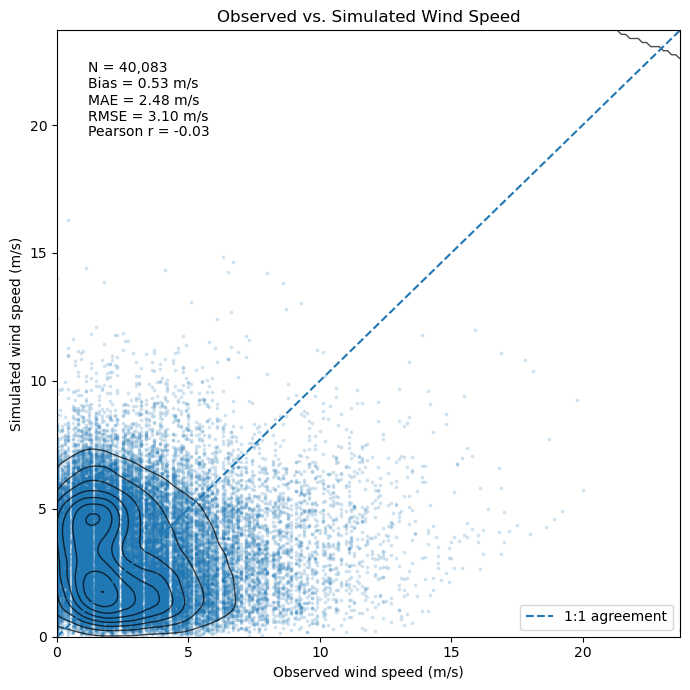

In [13]:
# Scatter Plot Observado vs simulado

wind_error = validation_df["wind_sim"] - validation_df["wind_obs"]

global_bias = wind_error.mean()
global_mae = wind_error.abs().mean()
global_rmse = np.sqrt(np.mean(wind_error**2))

global_r = stats.pearsonr(
    validation_df["wind_obs"],
    validation_df["wind_sim"]
).statistic


limit = max(
    validation_df["wind_obs"].max(),
    validation_df["wind_sim"].max()
)


fig, ax = plt.subplots(figsize=(7, 7))

# Scatter
ax.scatter(
    validation_df["wind_obs"],
    validation_df["wind_sim"],
    s=3,
    alpha=0.15,
    rasterized=True
)


# Lineas de densidad
x = validation_df["wind_obs"].to_numpy()
y = validation_df["wind_sim"].to_numpy()

xx, yy = np.mgrid[
    0:limit:150j,
    0:limit:150j
]

positions = np.vstack([
    xx.ravel(),
    yy.ravel()
])

values = np.vstack([x, y])

kernel = gaussian_kde(values)

density = np.reshape(
    kernel(positions).T,
    xx.shape
)

ax.contour(
    xx,
    yy,
    density,
    levels=8,
    linewidths=1,
    colors="black",
    alpha=0.7
)


# Linea 1:1
ax.plot(
    [0, limit],
    [0, limit],
    linestyle="--",
    linewidth=1.5,
    label="1:1 agreement"
)


metrics_text = (
    f"N = {len(validation_df):,}\n"
    f"Bias = {global_bias:.2f} m/s\n"
    f"MAE = {global_mae:.2f} m/s\n"
    f"RMSE = {global_rmse:.2f} m/s\n"
    f"Pearson r = {global_r:.2f}"
)

ax.text(
    0.05,
    0.95,
    metrics_text,
    transform=ax.transAxes,
    va="top"
)

ax.set(
    title="Observed vs. Simulated Wind Speed",
    xlabel="Observed wind speed (m/s)",
    ylabel="Simulated wind speed (m/s)",
    xlim=(0, limit),
    ylim=(0, limit)
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "observed_vs_simulated.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.2 Error de Velocidad del Viento por Estación

El MAE por estación se utiliza para comparar la magnitud del error de velocidad del viento dentro de la red de monitoreo.

Las estaciones se ordenan de menor a mayor MAE. A partir de este ranking se identifican automáticamente la estación con menor error, la estación ubicada en la posición central del ranking y la estación con mayor error.

Estas tres estaciones se utilizan posteriormente como casos representativos para el análisis de las series temporales.

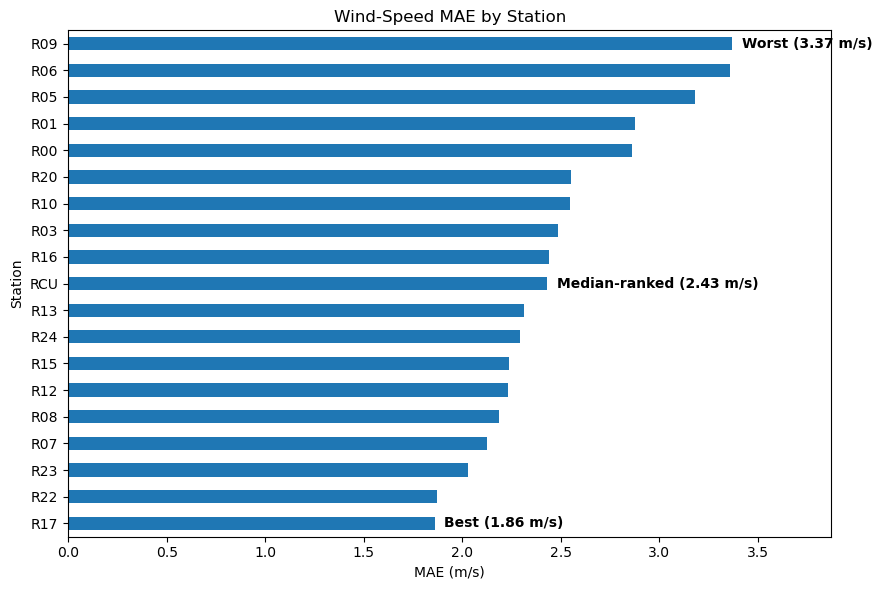

In [14]:
# Velocidad del viento por estación

station_mae = speed_metrics["MAE (m/s)"].sort_values()

# Estaciones representativas
best_station = station_mae.index[0]
median_position = len(station_mae) // 2
median_station = station_mae.index[median_position]
worst_station = station_mae.index[-1]

representative_stations = [
    best_station,
    median_station,
    worst_station
]

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

station_mae.plot(
    kind="barh",
    ax=ax
)

ax.set(
    title="Wind-Speed MAE by Station",
    xlabel="MAE (m/s)",
    ylabel="Station"
)

representative_labels = {
    best_station: "Best",
    median_station: "Median-ranked",
    worst_station: "Worst"
}

for i, (station, mae) in enumerate(station_mae.items()):

    if station in representative_labels:

        label = representative_labels[station]

        ax.text(
            mae + 0.05,
            i,
            f"{label} ({mae:.2f} m/s)",
            va="center",
            fontweight="bold"
        )

ax.set_xlim(
    0,
    station_mae.max() * 1.15
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "error_by_station.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.3 Series Temporales

Se analiza la serie de tiempo de tres estaciones seleccionadas objetivamente a partir del ranking de MAE:

- la estación con el menor MAE
- la estación ubicada en la posición central del ranking
- y la estación con el mayor MAE

Esta comparación permite evaluar si las diferencias observadas en las métricas agregadas también se reflejan en la evolución temporal de la velocidad del viento simulada y observada.

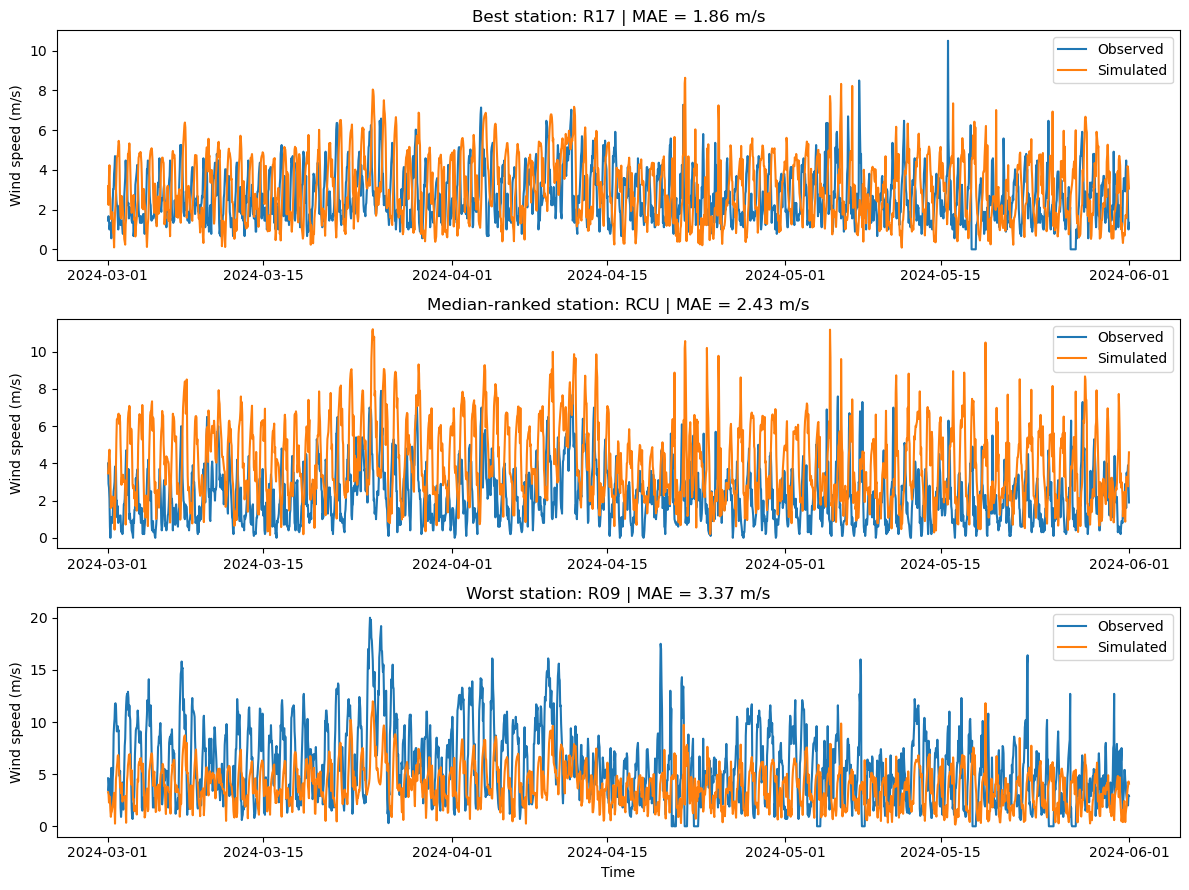

In [15]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=False
)

labels = ["Best", "Median-ranked", "Worst"]

for ax, station, label in zip(
    axes,
    representative_stations,
    labels
):
    station_data = validation_df[
        validation_df["station"] == station
    ]

    ax.plot(
        station_data["timestamp"],
        station_data["wind_obs"],
        label="Observed"
    )

    ax.plot(
        station_data["timestamp"],
        station_data["wind_sim"],
        label="Simulated"
    )

    mae = speed_metrics.loc[station, "MAE (m/s)"]

    ax.set_title(
        f"{label} station: {station} | MAE = {mae:.2f} m/s"
    )

    ax.set_ylabel("Wind speed (m/s)")
    ax.legend()

axes[-1].set_xlabel("Time")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "temporal_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 7.4 Error en la Dirección del Viento

La distribución del error angular con signo proporciona información adicional que no puede obtenerse únicamente mediante MAE y RMSE. Los errores cercanos a $0^\circ$ indican una mayor concordancia entre la dirección observada y simulada, mientras que valores cercanos a $\pm180^\circ$ representan direcciones prácticamente opuestas.

El signo del error indica el sentido del desplazamiento angular, mientras que su magnitud absoluta representa el grado de desacuerdo direccional.

In [16]:
validation_df["dir_error"] = angular_error(
    validation_df["dir_obs"],
    validation_df["dir_sim"]
)

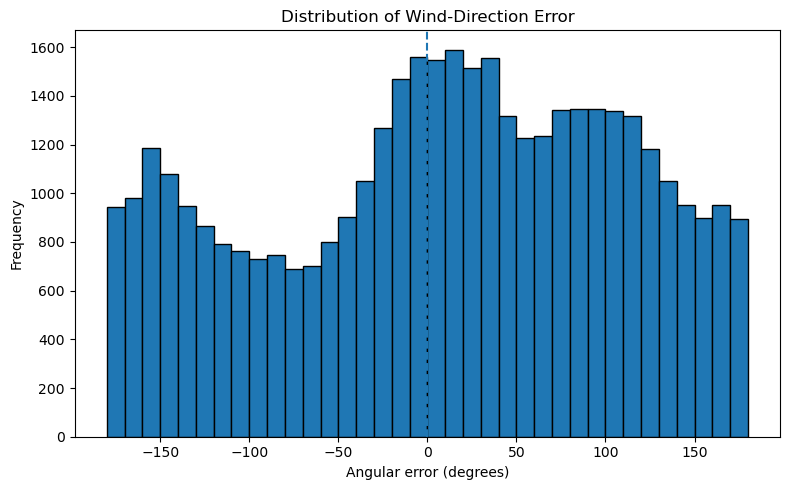

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    validation_df["dir_error"],
    bins=36,
    edgecolor="black"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set(
    title="Distribution of Wind-Direction Error",
    xlabel="Angular error (degrees)",
    ylabel="Frequency"
)

fig.tight_layout()
plt.show()

## 8. Análisis de Sensibilidad

La dirección del viento puede presentar una mayor variabilidad bajo condiciones de baja velocidad, donde pequeñas fluctuaciones pueden producir cambios importantes en el ángulo reportado. Para evaluar el efecto de estas condiciones sobre la validación de la dirección, las métricas de error circular se recalculan utilizando únicamente observaciones con velocidades del viento superiores a 2.0 m/s. Este procedimiento se considera un análisis de sensibilidad y no una etapa de limpieza de datos. La evaluación principal conserva todas las observaciones válidas.

In [18]:
baseline_error = validation_df["dir_error"]

moderate_wind_df = validation_df[
    validation_df["wind_obs"] > 2.0
].copy()

moderate_error = angular_error(
    moderate_wind_df["dir_obs"],
    moderate_wind_df["dir_sim"]
)


sensitivity_results = pd.DataFrame({
    "Condition": [
        "All observations",
        "Observed wind > 2 m/s"
    ],
    "N": [
        len(validation_df),
        len(moderate_wind_df)
    ],
    "Directional MAE (°)": [
        baseline_error.abs().mean(),
        moderate_error.abs().mean()
    ],
    "Directional RMSE (°)": [
        np.sqrt(np.mean(baseline_error**2)),
        np.sqrt(np.mean(moderate_error**2))
    ]
})

sensitivity_results["Retained data (%)"] = [
    100.0,
    100 * len(moderate_wind_df) / len(validation_df)
]

sensitivity_results.round(2)

,Condition,N,Directional MAE (°),Directional RMSE (°),Retained data (%)
0,All observations,40083,83.15,98.80,100.00
1,Observed wind > 2 m/s,21223,76.24,93.03,52.95


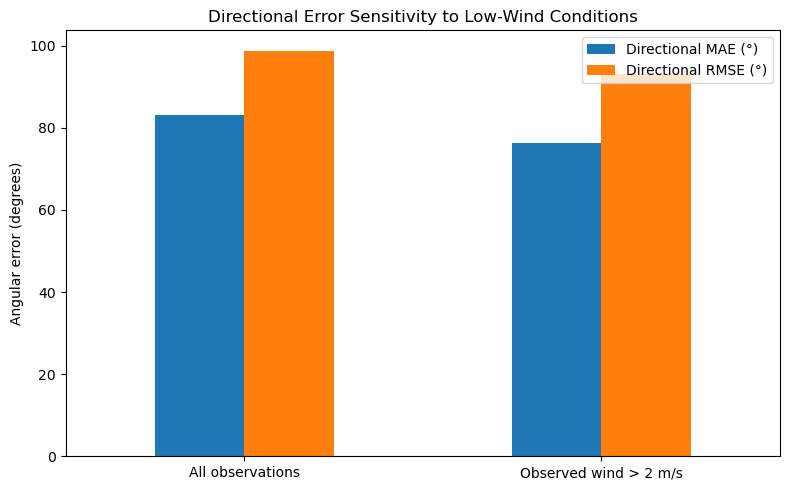

In [19]:
plot_data = sensitivity_results.set_index("Condition")[
    ["Directional MAE (°)", "Directional RMSE (°)"]
]

fig, ax = plt.subplots(figsize=(8, 5))

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set(
    title="Directional Error Sensitivity to Low-Wind Conditions",
    ylabel="Angular error (degrees)",
    xlabel=""
)

ax.tick_params(
    axis="x",
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "directional_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El análisis de sensibilidad muestra una reducción moderada del error direccional al excluir las condiciones anteriormente mencionadas. El MAE angular disminuye de aproximadamente 83.2° para el dataset completo a aproximadamente 76.2° cuando sólo se consideran observaciones superiores a 2 m/s. De manera similar, el RMSE angular disminuye de aproximadamente 98.8° a 93.0°.

Sin embargo, algo importante a mencionar es que en este caso se conserva aproximadamente 53% de los registros originales. Por lo tanto, aunque las observaciones de viento débil contribuyen al error direccional, continúa existiendo una discrepancia considerable entre la dirección observada y simulada incluso después de excluirlas.

## 9. Conclusiones

La validación incluyó 40,083 combinaciones estación-hora correspondientes a 19 estaciones de monitoreo, lo que representa aproximadamente 95.5% de las combinaciones estación-hora teóricamente disponibles entre el periodo de evaluación. El dataset simulado presentó cobertura horaria completa, mientras que los registros faltantes correspondieron a la disponibilidad de las observaciones.

El desempeño de la velocidad del viento mostró diferencias importantes entre estaciones. El MAE por estación se encontró aproximadamente entre 1.86 y 3.37 m/s, lo que evidencia que el desempeño de la simulación no fue espacialmente uniforme dentro de la red de monitoreo. Las métricas de error absoluto y la concordancia temporal mostraron que aunque varias estaciones presentaron valores moderados de MAE y RMSE, las correlaciones de Pearson fueron generalmente débiles, indicando una capacidad limitada para reproducir la variabilidad horaria observada de la velocidad del viento.

Para la dirección angular, el dataset completo presentó un MAE angular de aproximadamente 83.2°. Al restringir el análisis a velocidades observadas superiores a 2 m/s, el MAE disminuyó a aproximadamente 76.2°, aunque persistieron discrepancias importantes.

En conjunto, los resultados muestran la importancia de evaluar una simulación computacional mediante múltiples métricas complementarias. La magnitud del error, la correlación temporal, las diferencias entre estaciones y las estadísticas circulares de dirección describen aspectos distintos del comportamiento del modelo que no podrían identificarse utilizando una sola métrica.